# Stop Delay Change

Compares delay changes by next stop, or by city part when a stop-to-city-part mapping is available.

In [1]:
from pathlib import Path
import importlib.util
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "analysis"))

spec = importlib.util.spec_from_file_location(
    "stop_delay_change",
    PROJECT_ROOT / "analysis" / "stop-delay-change.py",
)
stop_delay_change = importlib.util.module_from_spec(spec)
spec.loader.exec_module(stop_delay_change)

DB = PROJECT_ROOT / "data" / "foli.db"
TIMEZONE = "Europe/Helsinki"
GTFS_DIR = None
LIMIT = 20
MIN_OBSERVATIONS = 100
GROUP_BY = "stop"  # "stop" or "city-part"
CITY_PARTS_CSV = None  # Example: PROJECT_ROOT / "data" / "stop-city-parts.csv"
SORT_BY = "absolute"  # "absolute", "increase", or "decrease"
LINE_REF = None
BASELINE_START = None
BASELINE_END = None
COMPARISON_START = None
COMPARISON_END = None

To aggregate by city part, set `GROUP_BY = "city-part"` and point `CITY_PARTS_CSV` at a CSV with `stop_id,city_part` columns.

In [2]:
class Args:
    db = DB
    timezone = TIMEZONE
    gtfs_dir = GTFS_DIR
    city_parts_csv = CITY_PARTS_CSV
    group_by = GROUP_BY
    sort_by = SORT_BY
    line_ref = LINE_REF
    baseline_start = BASELINE_START
    baseline_end = BASELINE_END
    comparison_start = COMPARISON_START
    comparison_end = COMPARISON_END
    min_observations = MIN_OBSERVATIONS
    limit = LIMIT

observations = stop_delay_change.load_observations(Args)
change, period_description = stop_delay_change.build_stop_change(Args, observations)
print(period_description)
change

baseline=2026-04-23T08:05:22+00:00..2026-04-25T06:28:30.500000+00:00, comparison=2026-04-25T06:28:30.500000+00:00..2026-04-27T04:51:39.000001+00:00


,stop_id,stop_name,city_part,stop_lat,stop_lon,baseline_obs_count,comparison_obs_count,baseline_avg_delay_min,comparison_avg_delay_min,delay_change_min,baseline_pct_late,comparison_pct_late,late_pct_point_change,baseline_pct_over_3_min_late,comparison_pct_over_3_min_late
2567,8138,Paraisten linja-autoasema,None,60.31,22.30,537,127,46.81,-3.90,-50.71,79.33,18.11,-61.22,71.69,0.00
1863,6043,Kaarina,None,60.41,22.37,798,1807,-11.00,-45.73,-34.74,26.69,17.10,-9.59,10.65,10.63
723,1993,"Linja-autoasema, laituri 3",None,60.46,22.27,2264,1283,2.20,31.53,29.33,15.55,57.44,41.90,10.29,53.00
632,1772,Haihuntie,None,60.54,22.37,466,345,20.06,-0.42,-20.48,68.03,41.16,-26.87,51.50,23.19
157,1169,Aluetalo,None,60.59,22.38,124,152,0.88,-17.17,-18.05,79.03,51.97,-27.06,9.68,1.97
1515,5025,Hanhenkaari,None,60.50,22.46,415,137,15.02,-0.65,-15.67,59.76,37.23,-22.53,44.82,13.87
1929,6111,Auranlaakson koulu,None,60.47,22.37,277,212,12.73,25.70,12.97,67.51,83.49,15.98,50.18,72.64
2716,8282,Korppoo,None,60.16,21.56,419,419,0.33,11.54,11.21,2.39,22.43,20.05,0.24,18.85
1200,346,Ypsilon,None,60.54,22.32,423,204,-10.92,-0.10,10.82,47.28,59.31,12.03,4.96,2.94
3122,972,Pläkkikaupunginkatu,None,60.46,22.21,265,287,0.62,-9.81,-10.43,47.55,27.53,-20.02,4.15,0.00


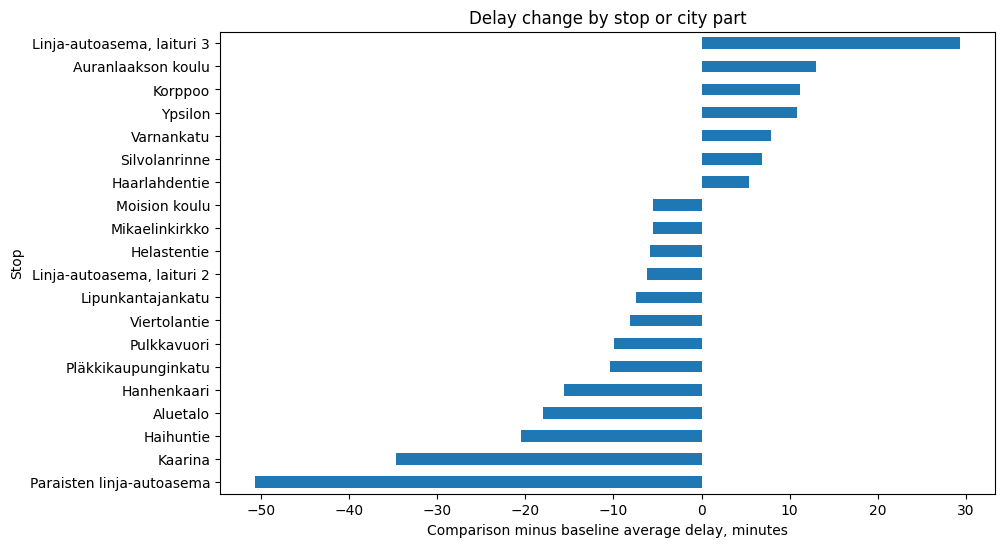

In [3]:
if not change.empty:
    label_column = "city_part" if GROUP_BY == "city-part" else "stop_name"
    ax = change.sort_values("delay_change_min").plot.barh(
        x=label_column,
        y="delay_change_min",
        legend=False,
        figsize=(10, 6),
        title="Delay change by stop or city part",
    )
    ax.set_xlabel("Comparison minus baseline average delay, minutes")
    ax.set_ylabel("City part" if GROUP_BY == "city-part" else "Stop")